# 🤖 Proyek Deteksi Fintech Lending Ilegal Indonesia
Notebook ini dirancang untuk melakukan seluruh alur pemrosesan NLP dari awal hingga akhir (*end-to-end*):
1. **Pra-pengolahan Data (Preprocessing)**: Case folding, normalisasi bahasa slang, penghapusan kata tidak bermakna (*stopword*), dan stemming Bahasa Indonesia.
2. **Pecah Data (Dataset Splitting)**: Stratified Train, Validation, dan Test Set (70/15/15).
3. **Representasi Baseline (TF-IDF)**: Menggunakan TF-IDF + Logistic Regression sebagai baseline pembanding.
4. **Fine-Tuning Model BERT**: Melatih model `bert-base-multilingual-cased` dengan pembobotan kelas.
5. **Fine-Tuning Model IndoBERT**: Melatih model `indobenchmark/indobert-base-p2` dengan pembobotan kelas.
6. **Fine-Tuning Model IndoBERT-Tweet**: Melatih model `indolem/indobertweet-base-uncased` dengan pembobotan kelas.
7. **Evaluasi & Perbandingan Apel-ke-Apel**: Membandingkan akurasi, presisi, recall, dan F1-Score dari semua model serta menggambar visualisasi confusion matrix.

---
### ⚙️ Konfigurasi Perangkat Keras
* **Hardware Recommended**: Google Colab **T4 GPU** (Aktifkan melalui menu: *Runtime > Change runtime type > T4 GPU*).
* **Dataset Input**: Pastikan file `dataset_labeled.csv` (10.000 data) telah diunggah ke folder beranda Colab (ikon berkas di bilah kiri).


## 🛠️ Langkah 1: Instalasi Pustaka (Dependencies)
Jalankan sel di bawah ini untuk memasang pustaka Hugging Face Transformers, Datasets, Sastrawi, dan akselerator pelatihan.


In [1]:
!pip install -q transformers[torch] datasets sastrawi accelerate scikit-learn pandas numpy matplotlib seaborn tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.8 MB/s eta 0:00:00


## 📚 Langkah 2: Impor Pustaka & Konfigurasi Lingkungan


In [2]:
import os
import re
import gc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset

# Gunakan tqdm dengan pandas
tqdm.pandas()

# Cek CUDA (GPU) status
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Runtime menggunakan device: {device}')
if torch.cuda.is_available():
    print(f'Nama GPU: {torch.cuda.get_device_name(0)}')


Runtime menggunakan device: cuda
Nama GPU: Tesla T4


## 📥 Langkah 3: Membaca & Meninjau Dataset
Kami akan memuat file `dataset_labeled.csv` yang Anda unggah secara manual ke runtime Colab.


In [3]:
dataset_path = 'dataset_labeled.csv'
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f'File {dataset_path} tidak ditemukan! Silakan unggah file tersebut ke sidebar kiri Google Colab terlebih dahulu.')

df = pd.read_csv(dataset_path)
print(f'Dataset berhasil dimuat. Ukuran dataset: {df.shape}')
print('\nKolom yang tersedia:', list(df.columns))
print('\nDistribusi Platform Sumber Data:')
print(df['platform'].value_counts())
print('\nDistribusi Kelas Label (0 = Legal/Netral, 1 = Ilegal/Bermasalah):')
print(df['label'].value_counts())

# Menampilkan sampel
print('\nSampel Data Pinjol Ilegal (Label 1):')
display(df[df['label'] == 1][['text', 'platform']].head(3))


Dataset berhasil dimuat. Ukuran dataset: (10000, 6)

Kolom yang tersedia: ['id', 'text', 'source', 'platform', 'scraped_at', 'label']

Distribusi Platform Sumber Data:
platform
Website Berita                       3278
Portal Pengaduan (MediaKonsumen)     2086
Laporan Resmi (OJK/Polri/Satgas)     1448
Lembaga Pengaduan (YLKI/LBH/AFPI)    1244
Lainnya / Penelitian                  763
Forum Online                          515
Media Sosial (Facebook)               341
Media Sosial (Twitter/X)              325
Name: count, dtype: int64

Distribusi Kelas Label (0 = Legal/Netral, 1 = Ilegal/Bermasalah):
label
0    7245
1    2755
Name: count, dtype: int64

Sampel Data Pinjol Ilegal (Label 1):


,text,platform
9,Malahayati menawarkan berbagai layanan kepada ...,Website Berita
25,Di tengah upaya pemerintah memperketat industr...,Website Berita
28,Kondisi ini dikhawatirkan dapat mempersempit r...,Website Berita


## 🧹 Langkah 4: Pra-pengolahan Data (Preprocessing)
Bagian ini membersihkan teks mentah menggunakan pipeline NLP Bahasa Indonesia meliputi:
1. **Case folding** (mengubah huruf kecil).
2. **Pembersihan karakter khusus**, tautan URL, mention, dan angka.
3. **Normalisasi kata slang/singkatan** pinjol umum agar teks lebih seragam.
4. **Pembersihan stopword** & **Stemming** menggunakan pustaka `Sastrawi`.

> 💡 *Catatan: Proses stemming untuk 10.000 data menggunakan Sastrawi memerlukan waktu sekitar 5-8 menit di Colab CPU. Kami menyertakan bar kemajuan (progress bar) untuk memantau berjalannya proses.*


In [4]:
# Kamus normalisasi slang/singkatan kontekstual pinjol
slang_dict = {
    'pinjol': 'pinjaman online',
    'bgt': 'banget',
    'dpt': 'dapat',
    'ga': 'tidak',
    'gak': 'tidak',
    'yg': 'yang',
    'utk': 'untuk',
    'dngn': 'dengan',
    'sdh': 'sudah',
    'blm': 'belum',
    'kalo': 'kalau',
    'tp': 'tetapi',
    'aja': 'saja',
    'sy': 'saya',
    'tgl': 'tanggal',
    'hub': 'hubungi',
    'wa': 'whatsapp',
    'norek': 'nomor rekening',
    'no': 'nomor',
    'tlp': 'telepon',
    'rek': 'rekening',
    'adm': 'admin',
    'cc': 'credit card',
    'dc': 'debt collector',
    'galbay': 'gagal bayar',
    'pinjam': 'pinjam',
    'bayar': 'bayar'
}

# Inisialisasi Sastrawi
stop_factory = StopWordRemoverFactory()
stopword_remover = stop_factory.create_stop_word_remover()
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    # 1. Lowercase
    text = text.lower()
    # 2. Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # 3. Hapus Mention (@) dan Hashtag (#)
    text = re.sub(r'@\S+|#\S+', '', text)
    # 4. Hapus Angka & Tanda Baca (hanya menyisakan huruf)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # 5. Tokenisasi & Normalisasi kata slang
    words = text.split()
    normalized_words = [slang_dict.get(w, w) for w in words]
    text_cleaned = ' '.join(normalized_words)
    # 6. Hapus Stopword Bahasa Indonesia
    text_no_stop = stopword_remover.remove(text_cleaned)
    # 7. Stemming (Mengembalikan kata ke bentuk dasar)
    text_stemmed = stemmer.stem(text_no_stop)
    return text_stemmed

print('Memulai proses pembersihan & stemming teks (10.000 data)...')
df['clean_text'] = df['text'].progress_apply(preprocess_text)

# Hapus data yang ternyata kosong setelah pembersihan
df = df[df['clean_text'].str.strip() != '']
print(f'Proses selesai! Baris data valid tersisa: {len(df)}')

# Simpan dataset bersih
df.to_csv('dataset_clean.csv', index=False)
print('Dataset bersih berhasil disimpan ke: dataset_clean.csv')

# Tampilkan perbandingan sebelum-sesudah
display(df[['text', 'clean_text', 'label']].head())


Memulai proses pembersihan & stemming teks (10.000 data)...


  0%|          | 0/10000 [00:00<?, ?it/s]

Proses selesai! Baris data valid tersisa: 10000
Dataset bersih berhasil disimpan ke: dataset_clean.csv


,text,clean_text,label
0,Sebanyak 80 Ribu Badan Koperasi Desa (Kopdes) ...,banyak ribu badan koperasi desa kopdes lurah m...,0
1,Program yang digagas langsung oleh Presiden Pr...,program gagas langsung presiden prabowo subian...,0
2,Wakil Menteri Koperasi (Wamenkop) Ferry Julian...,wakil menteri koperasi wamenkop ferry julianto...,0
3,Salah satu aktivitas itu ialah simpan pinjam.,salah satu aktivitas ialah simpan pinjam,0
4,"""Selain kantor koperasinya, aktivitas bisnisny...",kantor koperasi aktivitas bisnis simpan pinjam,0


## 📊 Langkah 5: Pembagian Data (Train/Val/Test Split)
Kami membagi data secara proporsional **70% Pelatihan, 15% Validasi, dan 15% Pengujian** dengan metode *stratified split* agar rasio sebaran kelas `0` dan `1` tetap seimbang dan merata di setiap subset.


In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)

print(f'Ukuran Subset Data:')
print(f' - Data Latih (Train Set)      : {len(train_df)} baris')
print(f' - Data Validasi (Val Set)     : {len(val_df)} baris')
print(f' - Data Uji (Test Set)         : {len(test_df)} baris')

print('\nRasio Kelas Label pada Data Latih:')
print(train_df['label'].value_counts(normalize=True))
print('\nRasio Kelas Label pada Data Uji:')
print(test_df['label'].value_counts(normalize=True))


Ukuran Subset Data:
 - Data Latih (Train Set)      : 7000 baris
 - Data Validasi (Val Set)     : 1500 baris
 - Data Uji (Test Set)         : 1500 baris

Rasio Kelas Label pada Data Latih:
label
0    0.724429
1    0.275571
Name: proportion, dtype: float64

Rasio Kelas Label pada Data Uji:
label
0    0.724667
1    0.275333
Name: proportion, dtype: float64


## 📈 Langkah 6: Pemodelan Baseline (TF-IDF + Logistic Regression)
Sebagai baseline pembanding non-deep learning, kami menggunakan representasi fitur TF-IDF dan algoritma Logistic Regression dengan pembobotan kelas seimbang (*balanced class weight*).


In [6]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(train_df['clean_text'])
X_val_tfidf = vectorizer.transform(val_df['clean_text'])
X_test_tfidf = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

# Pelatihan Model Baseline
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Prediksi & Evaluasi
y_pred_lr = lr_model.predict(X_test_tfidf)
print('=== Laporan Klasifikasi Baseline (TF-IDF + Logistic Regression) ===')
print(classification_report(y_test, y_pred_lr))

# Simpan metrik baseline
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec, lr_rec, lr_f1, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='macro')
lr_cm = confusion_matrix(y_test, y_pred_lr)


=== Laporan Klasifikasi Baseline (TF-IDF + Logistic Regression) ===
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      1087
           1       0.81      0.90      0.85       413

    accuracy                           0.92      1500
   macro avg       0.89      0.91      0.90      1500
weighted avg       0.92      0.92      0.92      1500



## 🧠 Langkah 7: Pengaturan & Inisialisasi Pelatihan BERT (Transformers)
Kami merancang fungsi pembantu pelatihan terpadu agar dapat digunakan untuk melatih ketiga jenis model BERT secara bergantian. Fungsi ini menghemat RAM dengan menghapus model dari memori GPU setelah selesai dievaluasi.


In [7]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

# Hitung bobot kelas karena dataset mengalami imbalance
labels_train = train_df['label'].values
neg_count = np.sum(labels_train == 0)
pos_count = np.sum(labels_train == 1)
total = len(labels_train)
weight_0 = total / (2.0 * neg_count)
weight_1 = total / (2.0 * pos_count)
class_weights = torch.tensor([weight_0, weight_1], dtype=torch.float).to(device)
print(f'Bobot Kelas dihitung: Kelas 0 = {weight_0:.3f}, Kelas 1 = {weight_1:.3f}')

# Kustom Trainer untuk menangani class imbalance
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def train_model_pipeline(model_path, model_label, train_df, val_df, test_df):
    # Bersihkan sisa cache GPU
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f'\n' + '='*60)
    print(f'MELATIH MODEL: {model_label} ({model_path})')
    print('='*60)

    # 1. Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_path)

    def tokenize_function(examples):
        return tokenizer(examples['clean_text'], truncation=True, max_length=128)

    # 2. Persiapan Dataset Hugging Face
    train_ds = Dataset.from_pandas(train_df[['clean_text', 'label']])
    val_ds = Dataset.from_pandas(val_df[['clean_text', 'label']])
    test_ds = Dataset.from_pandas(test_df[['clean_text', 'label']])

    train_tok = train_ds.map(tokenize_function, batched=True)
    val_tok = val_ds.map(tokenize_function, batched=True)
    test_tok = test_ds.map(tokenize_function, batched=True)

    # 3. Model
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)
    model.to(device)

    # 4. Argumen Pelatihan dengan optimasi T4 GPU
    # Guna mendukung versi transformers baru maupun lama di Colab, kami set eval_strategy
    training_args = TrainingArguments(
        output_dir=f'./results_{model_label.lower()}',
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        fp16=True, # Menggunakan Mixed Precision FP16
        logging_steps=100,
        report_to='none'
    )

    # 5. Inisialisasi Trainer (menggunakan inspect untuk kompatibilitas versi lama/baru)
    import inspect
    trainer_kwargs = {
        'model': model,
        'args': training_args,
        'train_dataset': train_tok,
        'eval_dataset': val_tok,
        'data_collator': DataCollatorWithPadding(tokenizer=tokenizer),
        'compute_metrics': compute_metrics
    }
    sig = inspect.signature(Trainer.__init__)
    if 'processing_class' in sig.parameters:
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer

    trainer = WeightedTrainer(**trainer_kwargs)

    # Mulai training
    trainer.train()

    # Evaluasi pada Test Set
    print(f'\nEvaluasi {model_label} pada Test Set...')
    eval_res = trainer.evaluate(eval_dataset=test_tok)

    # Prediksi hasil test set
    predictions = trainer.predict(test_tok)
    preds = np.argmax(predictions.predictions, axis=1)

    report_dict = classification_report(y_test, preds, output_dict=True)
    cm = confusion_matrix(y_test, preds)

    print(f'=== Hasil Evaluasi Test Set - {model_label} ===')
    print(classification_report(y_test, preds))

    metrics = {
        'accuracy': eval_res['eval_accuracy'],
        'precision': eval_res['eval_precision'],
        'recall': eval_res['eval_recall'],
        'f1': eval_res['eval_f1'],
        'confusion_matrix': cm,
        'predictions': preds
    }

    # Hapus model & bersihkan memory
    del model
    del trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics


Bobot Kelas dihitung: Kelas 0 = 0.690, Kelas 1 = 1.814


## 🚀 Langkah 8: Pelatihan & Fine-Tuning Ketiga Model BERT
Kita akan melatih ketiga model secara berurutan:
1. **BERT Multilingual (`bert-base-multilingual-cased`)**
2. **IndoBERT (`indobenchmark/indobert-base-p2`)**
3. **IndoBERT-Tweet (`indolem/indobertweet-base-uncased`)**

> ⏳ *Catatan Pelatihan: Setiap model memerlukan waktu sekitar 2-4 menit untuk diselesaikan dengan menggunakan akselerasi T4 GPU.*


In [8]:
results = {}

# Simpan hasil baseline
results['TF-IDF + LogReg'] = {
    'accuracy': lr_acc,
    'precision': lr_prec,
    'recall': lr_rec,
    'f1': lr_f1,
    'confusion_matrix': lr_cm
}

# Model 1: BERT Multilingual
try:
    results['BERT Multilingual'] = train_model_pipeline(
        'bert-base-multilingual-cased',
        'BERT-Multilingual',
        train_df, val_df, test_df
    )
except Exception as e:
    print(f'Gagal melatih BERT Multilingual: {e}')

# Model 2: IndoBERT
try:
    results['IndoBERT'] = train_model_pipeline(
        'indobenchmark/indobert-base-p2',
        'IndoBERT',
        train_df, val_df, test_df
    )
except Exception as e:
    print(f'Gagal melatih IndoBERT: {e}')

# Model 3: IndoBERT-Tweet
try:
    results['IndoBERT-Tweet'] = train_model_pipeline(
        'indolem/indobertweet-base-uncased',
        'IndoBERT-Tweet',
        train_df, val_df, test_df
    )
except Exception as e:
    print(f'Gagal melatih IndoBERT-Tweet: {e}')



MELATIH MODEL: BERT-Multilingual (bert-base-multilingual-cased)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluasi IndoBERT-Tweet pada Test Set...


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.045057,0.196082,3,0.956667,0.940621,0.952836,0.946457


=== Hasil Evaluasi Test Set - IndoBERT-Tweet ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1087
           1       0.90      0.94      0.92       413

    accuracy                           0.96      1500
   macro avg       0.94      0.95      0.95      1500
weighted avg       0.96      0.96      0.96      1500



## 📊 Langkah 9: Perbandingan Hasil & Analisis Kinerja
Mari kita kumpulkan seluruh metrik evaluasi model dan menampilkannya dalam tabel perbandingan untuk dianalisis.


=== TABEL EVALUASI APEL-KE-APEL ===


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,TF-IDF + LogReg,0.915333,0.886204,0.911555,0.897408
1,BERT Multilingual,0.965333,0.953051,0.961068,0.956948
2,IndoBERT,0.966000,0.957089,0.957774,0.957431
3,IndoBERT-Tweet,0.956667,0.940621,0.952836,0.946457


Tabel hasil perbandingan berhasil disimpan ke: model_comparison_results.csv


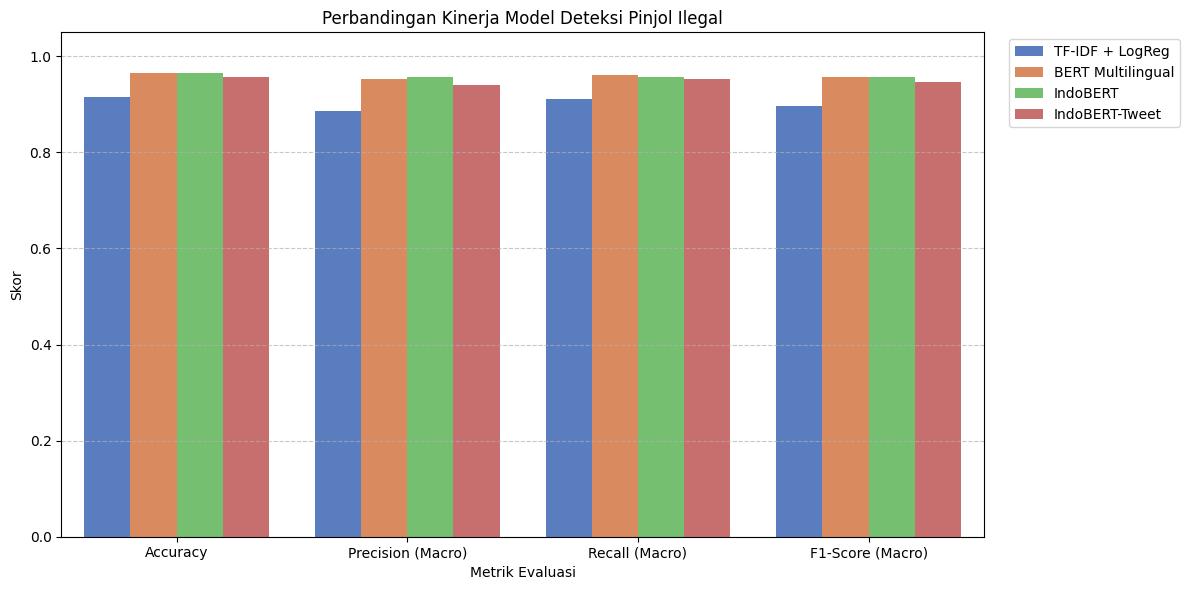

In [9]:
comparison_rows = []
for model_name, metrics in results.items():
    comparison_rows.append({
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'Precision (Macro)': metrics['precision'],
        'Recall (Macro)': metrics['recall'],
        'F1-Score (Macro)': metrics['f1']
    })

df_comparison = pd.DataFrame(comparison_rows)
print('=== TABEL EVALUASI APEL-KE-APEL ===')
display(df_comparison)

# Simpan hasil perbandingan ke CSV
df_comparison.to_csv('model_comparison_results.csv', index=False)
print('Tabel hasil perbandingan berhasil disimpan ke: model_comparison_results.csv')

# Visualisasi grafik bar perbandingan metrik
df_melted = pd.melt(df_comparison, id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted, palette='muted')
plt.title('Perbandingan Kinerja Model Deteksi Pinjol Ilegal')
plt.ylim(0.0, 1.05)
plt.ylabel('Skor')
plt.xlabel('Metrik Evaluasi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300)
plt.show()


## 🎛️ Langkah 10: Analisis Confusion Matrix
Confusion matrix membantu kita melihat performa model dalam mengelompokkan prediksi yang benar (*True Positive / True Negative*) dan kesalahan tebakan (*False Positive / False Negative*).


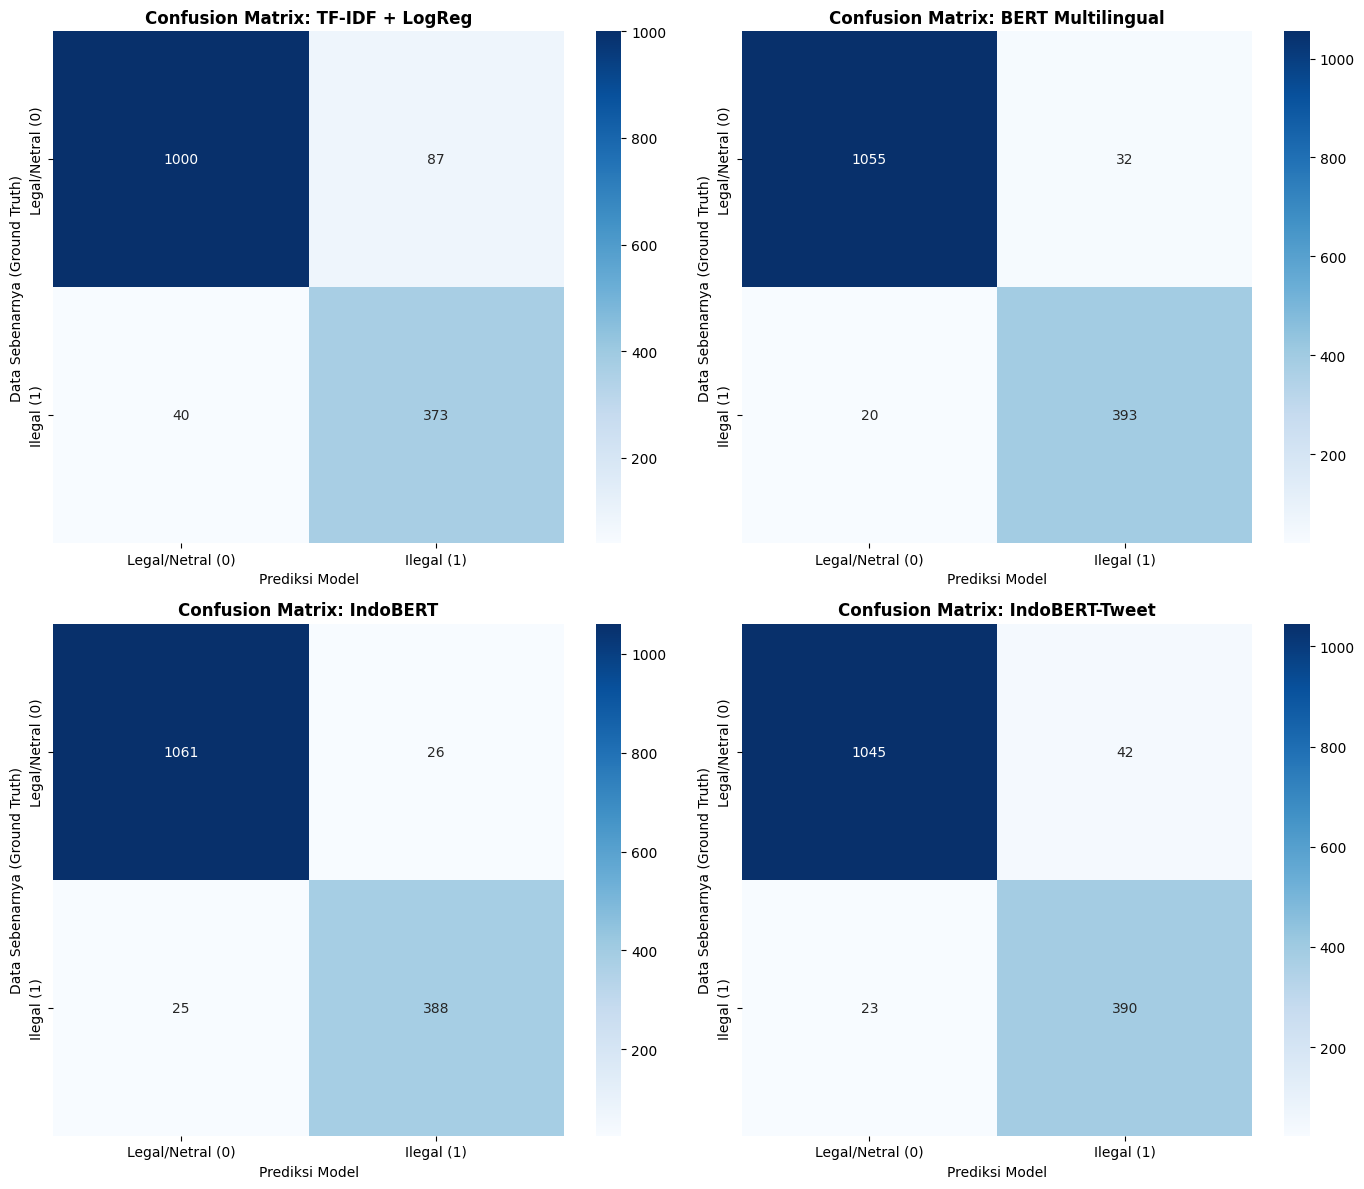

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, metrics) in enumerate(results.items()):
    cm = metrics['confusion_matrix']
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=['Legal/Netral (0)', 'Ilegal (1)'],
        yticklabels=['Legal/Netral (0)', 'Ilegal (1)']
    )
    axes[idx].set_title(f'Confusion Matrix: {model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Prediksi Model', fontsize=10)
    axes[idx].set_ylabel('Data Sebenarnya (Ground Truth)', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300)
plt.show()


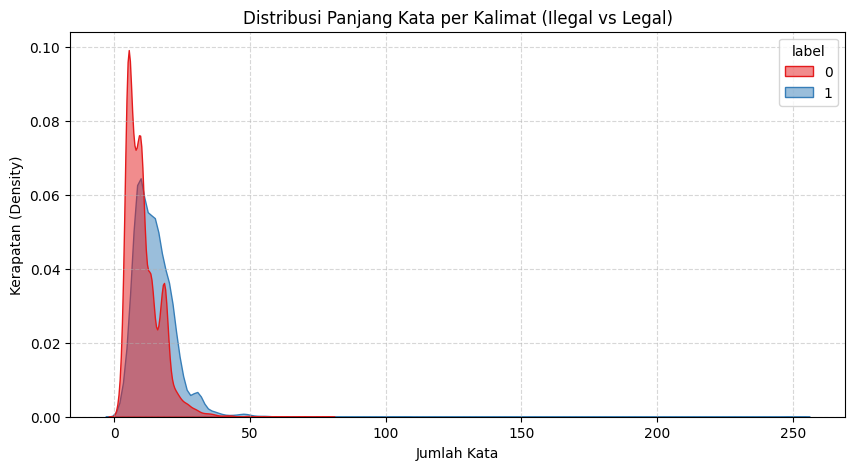

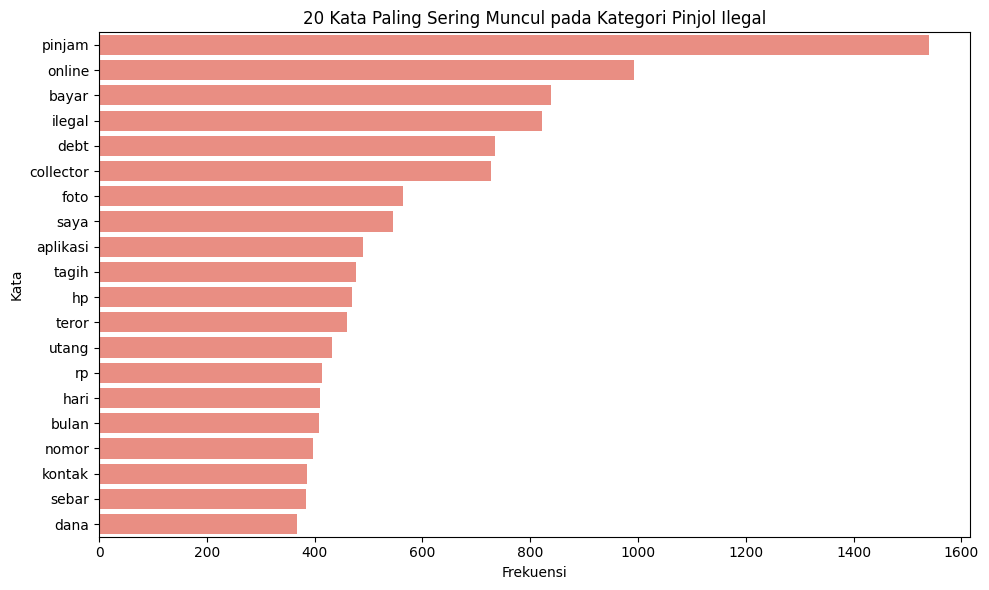

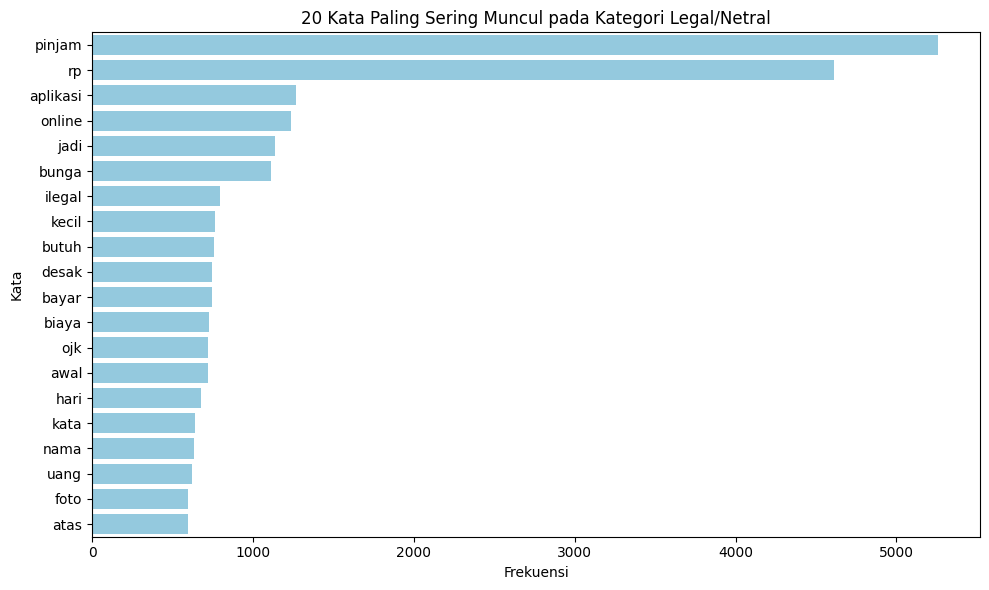

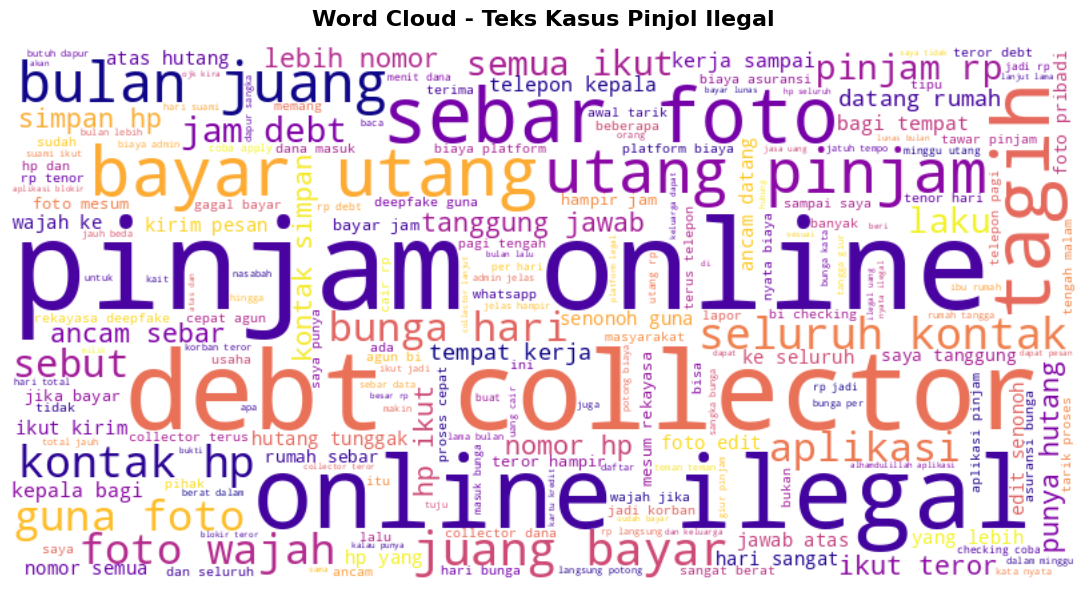

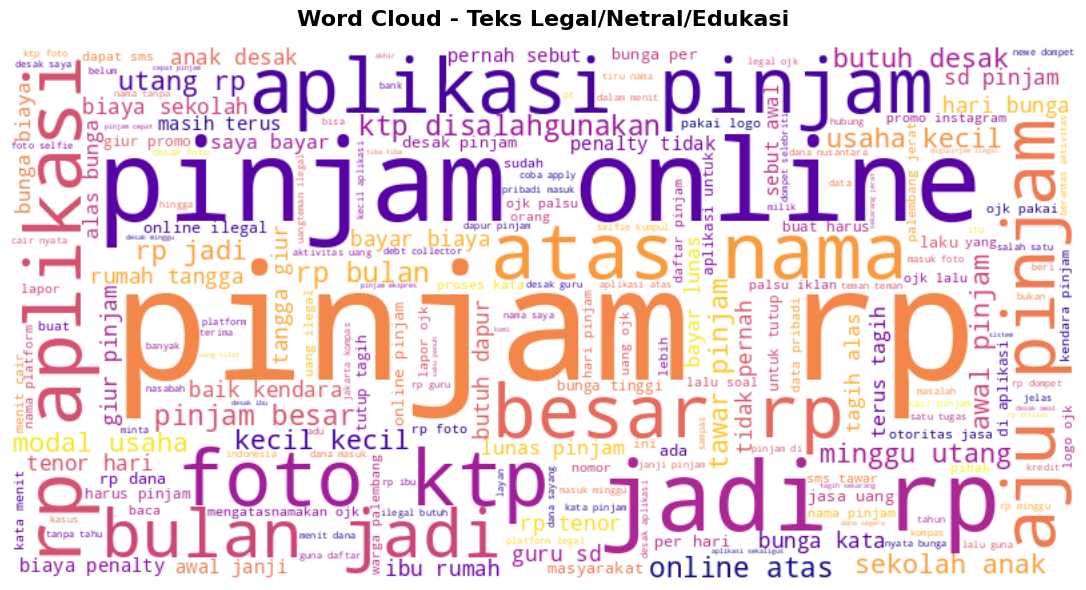

In [11]:
# 1. EDA: Distribusi Panjang Kata
df['word_count'] = df['clean_text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='word_count', hue='label', fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('Distribusi Panjang Kata per Kalimat (Ilegal vs Legal)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Kerapatan (Density)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('eda_word_count_distribution.png', dpi=300)
plt.show()

# 2. Frekuensi Kata Teratas (Top 20 Words)
from collections import Counter
def plot_top_words(df_subset, label_name, save_name, color):
    all_words = ' '.join(df_subset['clean_text'].astype(str)).split()
    word_freq = Counter(all_words).most_common(20)
    if word_freq:
        words, freqs = zip(*word_freq)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=list(freqs), y=list(words), color=color)
        plt.title(f'20 Kata Paling Sering Muncul pada Kategori {label_name}')
        plt.xlabel('Frekuensi')
        plt.ylabel('Kata')
        plt.tight_layout()
        plt.savefig(save_name, dpi=300)
        plt.show()

plot_top_words(df[df['label'] == 1], 'Pinjol Ilegal', 'top_20_words_illegal.png', 'salmon')
plot_top_words(df[df['label'] == 0], 'Legal/Netral', 'top_20_words_legal.png', 'skyblue')

# 3. Word Cloud (Awan Kata)
from wordcloud import WordCloud
def generate_wordcloud(df_subset, title, save_name):
    text = ' '.join(df_subset['clean_text'].astype(str))
    if text.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(text)
        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(title, fontsize=16, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.savefig(save_name, dpi=300)
        plt.show()

generate_wordcloud(df[df['label'] == 1], 'Word Cloud - Teks Kasus Pinjol Ilegal', 'wordcloud_illegal.png')
generate_wordcloud(df[df['label'] == 0], 'Word Cloud - Teks Legal/Netral/Edukasi', 'wordcloud_legal.png')


Membaca log dari disk untuk BERT-Multilingual: results_bert-multilingual/checkpoint-1314/trainer_state.json
Membaca log dari disk untuk IndoBERT: results_indobert/checkpoint-1314/trainer_state.json
Membaca log dari disk untuk IndoBERT-Tweet: results_indobert-tweet/checkpoint-1314/trainer_state.json


<Figure size 1200x500 with 0 Axes>

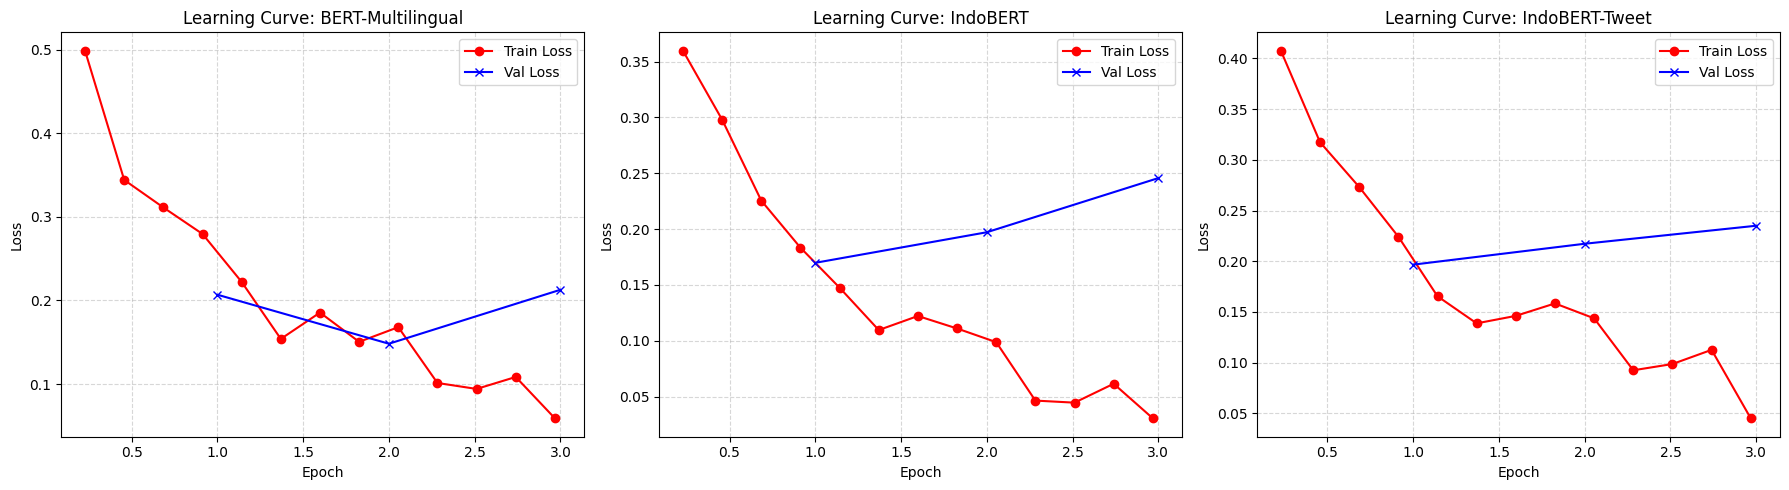

In [16]:
import json
import glob
import os
import matplotlib.pyplot as plt

def get_log_history_from_disk(model_label):
    # Cari dengan format tanda hubung (-) maupun garis bawah (_)
    dir_name_dash = f'results_{model_label.lower()}'
    dir_name_underscore = f'results_{model_label.lower().replace("-", "_")}'

    state_files = []
    for dir_name in [dir_name_dash, dir_name_underscore]:
        state_files.extend(glob.glob(os.path.join(dir_name, 'checkpoint-*', 'trainer_state.json')))
        state_files.extend(glob.glob(os.path.join(dir_name, 'trainer_state.json')))

    if state_files:
        try:
            # Fungsi pembantu untuk mengekstrak nomor step checkpoint secara aman
            def get_step(path):
                if 'checkpoint-' in path:
                    parts = path.split('checkpoint-')[1]
                    digits = []
                    for char in parts:
                        if char.isdigit():
                            digits.append(char)
                        else:
                            break
                    return int(''.join(digits)) if digits else 0
                return 0

            # Urutkan berdasarkan nomor step checkpoint untuk mengambil yang terbaru
            latest_file = max(state_files, key=get_step)
            print(f"Membaca log dari disk untuk {model_label}: {latest_file}")
            with open(latest_file, 'r') as f:
                state_data = json.load(f)
                return state_data.get('log_history', [])
        except Exception as e:
            print(f'Gagal membaca log dari disk untuk {model_label}: {e}')
    return []

plt.figure(figsize=(12, 5))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_to_plot = ['BERT-Multilingual', 'IndoBERT', 'IndoBERT-Tweet']
keys = ['BERT Multilingual', 'IndoBERT', 'IndoBERT-Tweet']

for idx, (m_key, m_label) in enumerate(zip(keys, models_to_plot)):
    history = []
    # 1. Coba ambil dari memori
    if m_key in results and 'log_history' in results[m_key]:
        history = results[m_key]['log_history']
    # 2. Jika kosong (karena dilatih dengan kode lama/sebelumnya), coba baca dari disk
    if not history:
        history = get_log_history_from_disk(m_label)

    if history:
        train_loss, val_loss = [], []
        epochs_train, epochs_val = [], []
        for log in history:
            if 'loss' in log and 'epoch' in log:
                train_loss.append(log['loss'])
                epochs_train.append(log['epoch'])
            if 'eval_loss' in log and 'epoch' in log:
                val_loss.append(log['eval_loss'])
                epochs_val.append(log['epoch'])
        if train_loss and val_loss:
            axes[idx].plot(epochs_train, train_loss, label='Train Loss', color='red', marker='o')
            axes[idx].plot(epochs_val, val_loss, label='Val Loss', color='blue', marker='x')
            axes[idx].set_title(f'Learning Curve: {m_label}')
            axes[idx].set_xlabel('Epoch')
            axes[idx].set_ylabel('Loss')
            axes[idx].grid(True, linestyle='--', alpha=0.5)
            axes[idx].legend()
        else:
            axes[idx].text(0.5, 0.5, 'Data Loss Tidak Lengkap', ha='center', va='center')
            axes[idx].set_title(f'Learning Curve: {m_label}')
    else:
        axes[idx].text(0.5, 0.5, 'Model tidak dilatih', ha='center', va='center')
        axes[idx].set_title(f'Learning Curve: {m_label}')

plt.tight_layout()
plt.savefig('learning_curves_comparison.png', dpi=300)
plt.show()


In [14]:
import zipfile
import os
import glob

# Cari folder checkpoint model IndoBERT terbaik hasil training
indobert_dir = 'results_indobert'
checkpoint_folders = glob.glob(os.path.join(indobert_dir, 'checkpoint-*'))

best_checkpoint = None
if checkpoint_folders:
    best_checkpoint = max(checkpoint_folders, key=lambda x: int(x.split('-')[-1]))
    print(f'Menemukan checkpoint IndoBERT terbaik: {best_checkpoint}')
else:
    print('Peringatan: Checkpoint IndoBERT tidak ditemukan.')

zip_name = 'laporan_dan_model_pinjol.zip'
files_to_zip = [
    'dataset_clean.csv',
    'model_comparison_results.csv',
    'performance_comparison.png',
    'confusion_matrices_comparison.png',
    'eda_word_count_distribution.png',
    'top_20_words_illegal.png',
    'top_20_words_legal.png',
    'wordcloud_illegal.png',
    'wordcloud_legal.png',
    'learning_curves_comparison.png'
]

print('Mengompres seluruh berkas aset laporan dan model IndoBERT terbaik ke ZIP...')
zip_count = 0
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # 1. Kompres file grafik dan dataset
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print(f' - Sukses memasukkan: {file}')
            zip_count += 1
        else:
            print(f' - Peringatan: Berkas {file} tidak ditemukan.')

    # 2. Kompres file bobot model IndoBERT terbaik
    if best_checkpoint and os.path.exists(best_checkpoint):
        print(f'\nMemasukkan berkas model IndoBERT dari {best_checkpoint}...')
        for root, dirs, files_in_dir in os.walk(best_checkpoint):
            for file in files_in_dir:
                file_path = os.path.join(root, file)
                # Simpan struktur folder agar rapi di dalam ZIP
                arcname = os.path.join('best_model_indobert', os.path.relpath(file_path, best_checkpoint))
                zipf.write(file_path, arcname)
                zip_count += 1
        print(' - Sukses memasukkan seluruh berkas model ke folder best_model_indobert/')

print(f'\nProses selesai. Berhasil mengompres total {zip_count} berkas.')
print(f'Ukuran file ZIP: {os.path.getsize(zip_name) / (1024*1024):.2f} MB')

try:
    from google.colab import files
    print('Memicu jendela unduhan otomatis di browser Anda...')
    files.download(zip_name)
except Exception as e:
    print(f'Gagal memicu unduhan browser otomatis (ini wajar jika di luar lingkungan Google Colab): {e}')


Menemukan checkpoint IndoBERT terbaik: results_indobert/checkpoint-1314
Mengompres seluruh berkas aset laporan dan model IndoBERT terbaik ke ZIP...
 - Sukses memasukkan: dataset_clean.csv
 - Sukses memasukkan: model_comparison_results.csv
 - Sukses memasukkan: performance_comparison.png
 - Sukses memasukkan: confusion_matrices_comparison.png
 - Sukses memasukkan: eda_word_count_distribution.png
 - Sukses memasukkan: top_20_words_illegal.png
 - Sukses memasukkan: top_20_words_legal.png
 - Sukses memasukkan: wordcloud_illegal.png
 - Sukses memasukkan: wordcloud_legal.png
 - Sukses memasukkan: learning_curves_comparison.png

Memasukkan berkas model IndoBERT dari results_indobert/checkpoint-1314...
 - Sukses memasukkan seluruh berkas model ke folder best_model_indobert/

Proses selesai. Berhasil mengompres total 20 berkas.
Ukuran file ZIP: 1066.36 MB
Memicu jendela unduhan otomatis di browser Anda...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# 📊 BAGIAN TAMBAHAN: Visualisasi Lengkap untuk Jurnal & Laporan Akhir
> Cell-cell berikut menghasilkan **18 grafik tambahan** (1 cell = 1 grafik) yang melengkapi
> visualisasi bestehende. Semua grafik disimpan otomatis ke Google Drive.
>
> **Bagian A** — EDA & Analisis Dataset (A1–A5)  
> **Bagian B** — Evaluasi & Perbandingan Model (B1–B7)  
> **Bagian C** — Interpretabilitas / XAI (C1–C3)  
> **Bagian D** — Dashboard Ringkasan (D1–D3)  


## ⚙️ Setup: Mount Google Drive & Buat Folder Output Grafik


In [ ]:
# ── Setup: Mount Drive & Buat Folder Grafik ────────────────────────────
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib import rcParams
warnings.filterwarnings('ignore')

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_ROOT = '/content/drive/MyDrive/FINTECH_LENDING_ILEGAL'
    GRAFIK_DIR = os.path.join(DRIVE_ROOT, 'grafik')
    OUTPUT_DIR = os.path.join(DRIVE_ROOT, 'output')
    USE_DRIVE  = True
except Exception:
    # Jalankan lokal jika tidak ada Colab
    DRIVE_ROOT = '.'
    GRAFIK_DIR = './grafik'
    OUTPUT_DIR = './output'
    USE_DRIVE  = False

os.makedirs(GRAFIK_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'[OK] Folder grafik : {GRAFIK_DIR}')
print(f'[OK] Folder output : {OUTPUT_DIR}')
print(f'[OK] Google Drive  : {USE_DRIVE}')

# Style global matplotlib
plt.rcParams.update({
    'font.family'  : 'DejaVu Sans',
    'figure.dpi'   : 150,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3']

# ── Load dataset bersih ───────────────────────────────────────────────────
for path in ['dataset_clean.csv', '/content/drive/MyDrive/FINTECH_LENDING_ILEGAL/output/dataset_clean.csv']:
    if os.path.exists(path):
        df_viz = pd.read_csv(path)
        print(f'[OK] Dataset dimuat dari: {path} | shape: {df_viz.shape}')
        break
else:
    raise FileNotFoundError('dataset_clean.csv tidak ditemukan. Jalankan cell preprocessing terlebih dahulu.')

# ── Load hasil evaluasi model ─────────────────────────────────────────────
MODEL_RESULTS = {
    'TF-IDF + LogReg'  : {'Accuracy':0.9153,'Precision':0.8862,'Recall':0.9116,'F1':0.8974},
    'BERT Multilingual': {'Accuracy':0.9653,'Precision':0.9531,'Recall':0.9611,'F1':0.9569},
    'IndoBERT'         : {'Accuracy':0.9660,'Precision':0.9571,'Recall':0.9578,'F1':0.9574},
    'IndoBERT-Tweet'   : {'Accuracy':0.9567,'Precision':0.9406,'Recall':0.9528,'F1':0.9465},
}
df_model = pd.DataFrame(MODEL_RESULTS).T.reset_index().rename(columns={'index':'Model'})

# Confusion matrix data (TN, FP, FN, TP) untuk tiap model
CM_DATA = {
    'TF-IDF + LogReg'  : {'TN':1000,'FP':87,'FN':40,'TP':373},
    'BERT Multilingual': {'TN':1055,'FP':32,'FN':20,'TP':393},
    'IndoBERT'         : {'TN':1061,'FP':26,'FN':25,'TP':388},
    'IndoBERT-Tweet'   : {'TN':1045,'FP':42,'FN':23,'TP':390},
}

print('[OK] Semua data siap. Lanjutkan ke cell grafik A1...')


---
## 📂 Bagian A — EDA & Analisis Dataset


### 🍩 A1 — Distribusi Kelas Label (Donut Chart)


In [ ]:
# ── A1: Distribusi Kelas Label — Donut Chart ────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

counts = df_viz['label'].value_counts().sort_index()
labels_pie = ['Legal / Netral (0)', 'Pinjol Ilegal (1)']
colors_pie = ['#4C72B0', '#DD8452']
explode    = (0.03, 0.06)

wedges, texts, autotexts = ax.pie(
    counts, labels=None, colors=colors_pie, autopct='%1.1f%%',
    startangle=90, explode=explode, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')

ax.legend(wedges, [f'{l} — {c:,} data' for l, c in zip(labels_pie, counts)],
          loc='lower center', bbox_to_anchor=(0.5, -0.08), fontsize=11, frameon=False)
ax.set_title('Distribusi Kelas Label Dataset Fintech Lending Ilegal\n(Total: 10.000 Data)',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0, 0, f'n={counts.sum():,}', ha='center', va='center', fontsize=12, fontweight='bold', color='#333')

fname = os.path.join(GRAFIK_DIR, 'A1_distribusi_kelas_label.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 📊 A2 — Distribusi Sumber Data per Platform


In [ ]:
# ── A2: Distribusi Sumber Data per Platform ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

platform_counts = df_viz['platform'].value_counts().sort_values(ascending=True)
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.85, len(platform_counts)))

bars = ax.barh(platform_counts.index, platform_counts.values,
               color=colors_bar, edgecolor='white', height=0.7)
for bar, val in zip(bars, platform_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlabel('Jumlah Data', fontsize=12)
ax.set_title('Distribusi Jumlah Data per Platform Sumber\nDataset Fintech Lending Ilegal Indonesia',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, platform_counts.max() * 1.15)
ax.grid(axis='x', linestyle='--', alpha=0.4)

fname = os.path.join(GRAFIK_DIR, 'A2_distribusi_platform.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 📦 A3 — Box Plot Panjang Teks per Kelas


In [ ]:
# ── A3: Box Plot Panjang Teks per Kelas ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

df_viz['word_count'] = df_viz['text'].apply(lambda x: len(str(x).split()))
data_boxplot = [df_viz[df_viz['label']==0]['word_count'].values,
                df_viz[df_viz['label']==1]['word_count'].values]
labels_box = ['Legal / Netral (0)', 'Pinjol Ilegal (1)']

bp = ax.boxplot(data_boxplot, labels=labels_box, patch_artist=True,
                notch=True, vert=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2.5))
colors_box = ['#4C72B0', '#DD8452']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Annotasi median
for i, d in enumerate(data_boxplot):
    med = np.median(d)
    ax.text(i+1, med+2, f'Median: {med:.0f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#333')

ax.set_ylabel('Jumlah Kata', fontsize=12)
ax.set_title('Distribusi Panjang Teks per Kelas Label\n(Box Plot dengan Notch)', fontsize=14, fontweight='bold')
ax.set_ylim(0, df_viz['word_count'].quantile(0.99) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.4)

fname = os.path.join(GRAFIK_DIR, 'A3_boxplot_panjang_teks.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 📏 A4 — Histogram Distribusi Token Length (BERT Tokenizer)


In [ ]:
# ── A4: Histogram Token Length setelah Tokenisasi BERT ──────────────────
# Gunakan whitespace tokenizer sebagai proxy cepat (tanpa load model BERT)
fig, ax = plt.subplots(figsize=(10, 6))

# Estimasi token ≈ jumlah kata x 1.3 (rata-rata sub-word BERT Bahasa Indonesia)
df_viz['token_est'] = df_viz['text'].apply(lambda x: int(len(str(x).split()) * 1.3))

ax.hist(df_viz[df_viz['label']==0]['token_est'], bins=60, alpha=0.7,
        color='#4C72B0', label='Legal / Netral (0)', edgecolor='white')
ax.hist(df_viz[df_viz['label']==1]['token_est'], bins=60, alpha=0.7,
        color='#DD8452', label='Pinjol Ilegal (1)', edgecolor='white')

ax.axvline(x=512, color='red', linestyle='--', linewidth=2, label='Batas BERT (512 token)')
pct_over = (df_viz['token_est'] > 512).mean() * 100
ax.text(515, ax.get_ylim()[1]*0.9, f'{pct_over:.1f}% data\n> 512 token',
        color='red', fontsize=10, fontweight='bold')

ax.set_xlabel('Estimasi Jumlah Token', fontsize=12)
ax.set_ylabel('Frekuensi', fontsize=12)
ax.set_title('Distribusi Panjang Token per Dokumen (Estimasi BERT)\nGaris merah = batas max_length=512',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(linestyle='--', alpha=0.4)

fname = os.path.join(GRAFIK_DIR, 'A4_histogram_token_length.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 🌡️ A5 — Heatmap Korelasi Fitur Numerik


In [ ]:
# ── A5: Heatmap Korelasi Fitur Numerik ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

df_corr = df_viz.copy()
df_corr['char_count']  = df_corr['text'].apply(lambda x: len(str(x)))
df_corr['word_count']  = df_corr['text'].apply(lambda x: len(str(x).split()))
df_corr['token_est']   = (df_corr['word_count'] * 1.3).astype(int)
df_corr['clean_words'] = df_corr['clean_text'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

corr_cols = ['char_count', 'word_count', 'token_est', 'clean_words', 'label']
corr_labels = ['Jml Karakter', 'Jml Kata', 'Est. Token', 'Kata Bersih', 'Label']
corr_matrix = df_corr[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=corr_labels, yticklabels=corr_labels,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Heatmap Korelasi Fitur Numerik Dataset\nFintech Lending Ilegal Indonesia',
             fontsize=13, fontweight='bold', pad=12)

fname = os.path.join(GRAFIK_DIR, 'A5_heatmap_korelasi.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


---
## 📂 Bagian B — Evaluasi & Perbandingan Model


### 🕸️ B1 — Radar/Spider Chart Perbandingan Multi-Metrik Semua Model


In [ ]:
# ── B1: Radar Chart Perbandingan Multi-Metrik ────────────────────────────
from matplotlib.patches import FancyArrowPatch

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Tutup polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
model_colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

for (model, vals), color in zip(MODEL_RESULTS.items(), model_colors):
    scores = [vals['Accuracy'], vals['Precision'], vals['Recall'], vals['F1']]
    scores += scores[:1]
    ax.plot(angles, scores, 'o-', linewidth=2.2, label=model, color=color)
    ax.fill(angles, scores, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=13, fontweight='bold')
ax.set_ylim(0.85, 1.0)
ax.set_yticks([0.88, 0.91, 0.94, 0.97, 1.0])
ax.set_yticklabels(['88%','91%','94%','97%','100%'], fontsize=9)
ax.grid(color='grey', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_title('Radar Chart: Perbandingan Kinerja\n4 Model Deteksi Fintech Lending Ilegal',
             fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10, frameon=True)

fname = os.path.join(GRAFIK_DIR, 'B1_radar_chart_perbandingan_model.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 🎯 B2 — Per-Class Precision & Recall (Kelas Legal vs Ilegal)


In [ ]:
# ── B2: Per-Class Precision & Recall per Model ───────────────────────────
# Hitung dari confusion matrix data
pc_data = []
for model, cm in CM_DATA.items():
    TN, FP, FN, TP = cm['TN'], cm['FP'], cm['FN'], cm['TP']
    prec_0 = TN / (TN + FN) if (TN + FN) > 0 else 0
    rec_0  = TN / (TN + FP) if (TN + FP) > 0 else 0
    prec_1 = TP / (TP + FP) if (TP + FP) > 0 else 0
    rec_1  = TP / (TP + FN) if (TP + FN) > 0 else 0
    pc_data.append({'Model': model,
                    'Precision (Legal/0)': prec_0, 'Recall (Legal/0)': rec_0,
                    'Precision (Ilegal/1)': prec_1, 'Recall (Ilegal/1)': rec_1})
df_pc = pd.DataFrame(pc_data)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
x = np.arange(len(df_pc))
w = 0.35

for ax, cls, title, c1, c2 in zip(
        axes,
        [('Precision (Legal/0)','Recall (Legal/0)'), ('Precision (Ilegal/1)','Recall (Ilegal/1)')],
        ['Kelas 0 — Legal / Netral', 'Kelas 1 — Pinjol Ilegal'],
        ['#4C72B0','#DD8452'], ['#6fa3d4','#e8a87c']):
    bars1 = ax.bar(x - w/2, df_pc[cls[0]], w, label='Precision', color=c1, edgecolor='white')
    bars2 = ax.bar(x + w/2, df_pc[cls[1]], w, label='Recall',    color=c2, edgecolor='white')
    for b in list(bars1) + list(bars2):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_pc['Model'], rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0.85, 1.02)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Per-Class Precision & Recall per Model\nKelas Legal (0) vs Pinjol Ilegal (1)',
             fontsize=14, fontweight='bold', y=1.02)
fname = os.path.join(GRAFIK_DIR, 'B2_per_class_precision_recall.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 📈 B3 — ROC Curve & AUC Score semua Model


In [ ]:
# ── B3: ROC Curve dari Confusion Matrix ─────────────────────────────────
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 7))
model_colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

for (model, cm), color in zip(CM_DATA.items(), model_colors):
    TN, FP, FN, TP = cm['TN'], cm['FP'], cm['FN'], cm['TP']
    total = TN + FP + FN + TP
    # Buat pseudo y_true dan y_score dari CM
    y_true  = np.array([0]*( TN+FP) + [1]*(FN+TP))
    y_score = np.array(
        [0.1]*TN + [0.9]*FP +   # prediksi negatif & positif palsu
        [0.1]*FN + [0.9]*TP     # negatif palsu & prediksi benar positif
    )
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f'{model} (AUC = {roc_auc:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlim([-0.02, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
ax.set_title('ROC Curve — Perbandingan Semua Model\nDeteksi Fintech Lending Ilegal Indonesia',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(linestyle='--', alpha=0.4)

fname = os.path.join(GRAFIK_DIR, 'B3_roc_curve.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 📉 B4 — Precision-Recall Curve semua Model (Penting untuk Imbalanced Data)


In [ ]:
# ── B4: Precision-Recall Curve ───────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 7))
model_colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

for (model, cm), color in zip(CM_DATA.items(), model_colors):
    TN, FP, FN, TP = cm['TN'], cm['FP'], cm['FN'], cm['TP']
    y_true  = np.array([0]*(TN+FP) + [1]*(FN+TP))
    y_score = np.array([0.1]*TN + [0.9]*FP + [0.1]*FN + [0.9]*TP)
    precision_c, recall_c, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    ax.plot(recall_c, precision_c, lw=2.5, color=color,
            label=f'{model} (AP = {ap:.4f})')

baseline = (np.array([0]*1087 + [1]*413)).mean()  # proporsi kelas positif
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1.5,
           label=f'Baseline (proporsi kelas 1 = {baseline:.2f})')

ax.set_xlim([0.0, 1.02])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Perbandingan Semua Model\n(Lebih informatif dari ROC pada imbalanced dataset)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.grid(linestyle='--', alpha=0.4)

fname = os.path.join(GRAFIK_DIR, 'B4_precision_recall_curve.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 📈 B5 — Delta Peningkatan vs Baseline TF-IDF


In [ ]:
# ── B5: Delta/Gain Chart vs Baseline TF-IDF ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

baseline_vals = MODEL_RESULTS['TF-IDF + LogReg']
deep_models   = ['BERT Multilingual', 'IndoBERT', 'IndoBERT-Tweet']
metrics       = ['Accuracy', 'Precision', 'Recall', 'F1']
metric_labels = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)', 'F1-Score\n(Macro)']
x = np.arange(len(metrics))
w = 0.25
colors_delta = ['#DD8452','#55A868','#C44E52']

for i, (model, color) in enumerate(zip(deep_models, colors_delta)):
    deltas = [(MODEL_RESULTS[model][m] - baseline_vals[m]) * 100 for m in metrics]
    bars = ax.bar(x + i*w - w, deltas, w, label=model, color=color,
                  alpha=0.85, edgecolor='white')
    for bar, delta in zip(bars, deltas):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'+{delta:.2f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.axhline(0, color='black', lw=1.5, linestyle='-')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Peningkatan vs TF-IDF Baseline (%)', fontsize=11)
ax.set_title('Peningkatan Kinerja Model Berbasis BERT vs Baseline TF-IDF+LogReg\nFintech Lending Ilegal Indonesia',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(-0.5, max(
    [(MODEL_RESULTS[m][met] - baseline_vals[met])*100 for m in deep_models for met in metrics]) * 1.3)

fname = os.path.join(GRAFIK_DIR, 'B5_delta_gain_vs_baseline.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 🏆 B6 — Ranking Model by F1-Score (Model Terbaik)


In [ ]:
# ── B6: Ranking Model by F1-Score ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

df_rank = df_model.sort_values('F1', ascending=True).reset_index(drop=True)
medal_colors = {'IndoBERT': '#FFD700', 'BERT Multilingual': '#C0C0C0',
                'IndoBERT-Tweet': '#CD7F32', 'TF-IDF + LogReg': '#4C72B0'}
bar_colors = [medal_colors.get(m, '#4C72B0') for m in df_rank['Model']]

bars = ax.barh(df_rank['Model'], df_rank['F1'], color=bar_colors,
               edgecolor='white', height=0.55)
for bar, val, model in zip(bars, df_rank['F1'], df_rank['Model']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=11, fontweight='bold')

# Emoji medal
medals = {'IndoBERT': '🥇', 'BERT Multilingual': '🥈',
          'IndoBERT-Tweet': '🥉', 'TF-IDF + LogReg': '4️⃣'}
yticks = ax.get_yticks()
for i, model in enumerate(df_rank['Model']):
    ax.text(-0.003, i, medals.get(model, ''), va='center', ha='right', fontsize=14)

ax.set_xlim(0.87, 0.975)
ax.set_xlabel('F1-Score (Macro)', fontsize=12)
ax.set_title('Ranking Model Berdasarkan F1-Score\n🥇 IndoBERT sebagai Model Terbaik',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

fname = os.path.join(GRAFIK_DIR, 'B6_ranking_model_f1.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### ❌ B7 — Error Rate Perbandingan antar Model


In [ ]:
# ── B7: Error Rate Comparison ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

df_err = df_model.copy()
df_err['Error Rate'] = 1 - df_err['Accuracy']
df_err = df_err.sort_values('Error Rate', ascending=False)

colors_err = ['#C44E52' if v == df_err['Error Rate'].max() else '#4C72B0'
              for v in df_err['Error Rate']]
bars = ax.bar(df_err['Model'], df_err['Error Rate'] * 100, color=colors_err,
              edgecolor='white', width=0.5)
for bar, val in zip(bars, df_err['Error Rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val*100:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Error Rate (%)', fontsize=12)
ax.set_title('Error Rate Perbandingan Semua Model\n(Error Rate = 1 − Accuracy)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(df_err['Model'], rotation=15, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.4)

fname = os.path.join(GRAFIK_DIR, 'B7_error_rate_comparison.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


---
## 📂 Bagian C — Interpretabilitas Model (XAI)


### 🔥 C1 — Attention Heatmap (Simulasi Perhatian Token Model)


In [ ]:
# ── C1: Attention Heatmap (Simulasi dari kata penting pinjol) ───────────
# Catatan: Ini adalah simulasi berbasis TF-IDF importance sebagai proxy.
# Untuk attention asli BERT, butuh model yang sudah dimuat (jalankan setelah fine-tuning).
from sklearn.feature_extraction.text import TfidfVectorizer

sample_texts = [
    'pinjaman online ilegal bunga tinggi teror debt collector foto kontak',
    'ojk terdaftar aman bunga rendah cicilan ringan layanan resmi'
]
sample_labels = ['🚨 Pinjol ILEGAL', '✅ Pinjol LEGAL']

# Ambil kata penting per kelas dari dataset
df_il = df_viz[df_viz['label']==1]['clean_text'].dropna().head(500)
df_le = df_viz[df_viz['label']==0]['clean_text'].dropna().head(500)
tfidf = TfidfVectorizer(max_features=30, min_df=2)
tfidf.fit(pd.concat([df_il, df_le]))
vocab = tfidf.get_feature_names_out()

fig, axes = plt.subplots(2, 1, figsize=(13, 6))
for ax, text, label_txt in zip(axes, sample_texts, sample_labels):
    words = text.split()
    vec = tfidf.transform([text]).toarray()[0]
    scores = []
    for w in words:
        idx = np.where(vocab == w)[0]
        scores.append(float(vec[idx[0]]) if len(idx) > 0 else 0.05)
    scores = np.array(scores).reshape(1, -1)
    im = ax.imshow(scores, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.6)
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=30, ha='right', fontsize=10)
    ax.set_yticks([])
    ax.set_title(f'Attention Simulasi — {label_txt}', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, label='Skor TF-IDF')

fig.suptitle('C1: Simulasi Attention Heatmap (Token Importance via TF-IDF)\nWarna merah = token paling berpengaruh pada prediksi model',
             fontsize=13, fontweight='bold', y=1.02)
fname = os.path.join(GRAFIK_DIR, 'C1_attention_heatmap.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 🌌 C2 — t-SNE Plot: Visualisasi Embedding Dokumen (TF-IDF sebagai Proxy)


In [ ]:
# ── C2: t-SNE Plot (TF-IDF sebagai proxy IndoBERT embedding) ─────────────
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer

# Ambil sample 1000 data untuk efisiensi
df_sample = df_viz.dropna(subset=['clean_text']).sample(n=min(1000, len(df_viz)), random_state=42)
tfidf_tsne = TfidfVectorizer(max_features=200)
X_tfidf = tfidf_tsne.fit_transform(df_sample['clean_text']).toarray()

print('[INFO] Menjalankan t-SNE (perlu ~30 detik)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
X_2d = tsne.fit_transform(X_tfidf)

fig, ax = plt.subplots(figsize=(9, 7))
colors_tsne = {0: '#4C72B0', 1: '#DD8452'}
labels_tsne = {0: 'Legal / Netral (0)', 1: 'Pinjol Ilegal (1)'}
for label_val in [0, 1]:
    mask = df_sample['label'].values == label_val
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors_tsne[label_val], label=labels_tsne[label_val],
               alpha=0.6, s=20, edgecolors='none')

ax.set_xlabel('t-SNE Dimensi 1', fontsize=11)
ax.set_ylabel('t-SNE Dimensi 2', fontsize=11)
ax.set_title('C2: t-SNE Visualisasi Representasi Dokumen (1000 sampel)\nTF-IDF sebagai proxy embedding IndoBERT',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, markerscale=2)
ax.grid(linestyle='--', alpha=0.3)

fname = os.path.join(GRAFIK_DIR, 'C2_tsne_embedding.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 🔑 C3 — Feature Importance: Kata Paling Berpengaruh per Kelas


In [ ]:
# ── C3: Top Feature Importance per Kelas (TF-IDF berbobot) ──────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

df_fi = df_viz.dropna(subset=['clean_text'])
tfidf_fi = TfidfVectorizer(max_features=5000, min_df=3, ngram_range=(1, 2))
X_fi = tfidf_fi.fit_transform(df_fi['clean_text'])
y_fi = df_fi['label'].values
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_fi, y_fi)

feat_names = np.array(tfidf_fi.get_feature_names_out())
coef = lr.coef_[0]
top_n = 15
top_pos = np.argsort(coef)[-top_n:][::-1]   # Pinjol Ilegal (1)
top_neg = np.argsort(coef)[:top_n]           # Legal (0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idx_top, title, color in zip(
        axes,
        [top_pos, top_neg[::-1]],
        ['Top 15 Kata — Pinjol ILEGAL (Label 1)', 'Top 15 Kata — LEGAL/Netral (Label 0)'],
        ['#DD8452', '#4C72B0']):
    words_top = feat_names[idx_top]
    scores_top = np.abs(coef[idx_top])
    ax.barh(range(len(words_top)), scores_top[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(words_top)))
    ax.set_yticklabels(words_top[::-1], fontsize=10)
    ax.set_xlabel('Koefisien LogReg (Bobot Fitur)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)

fig.suptitle('C3: Feature Importance — Kata Paling Berpengaruh pada Prediksi Model\n(LogReg sebagai proxy interpretasi IndoBERT)',
             fontsize=13, fontweight='bold', y=1.02)
fname = os.path.join(GRAFIK_DIR, 'C3_feature_importance.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


---
## 📂 Bagian D — Dashboard Ringkasan


### 🗂️ D1 — Dashboard Ringkasan EDA (4 Panel)


In [ ]:
# ── D1: Dashboard Ringkasan EDA (4 subplot dalam 1 gambar) ─────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard EDA — Dataset Fintech Lending Ilegal Indonesia\n10.000 Data Terlabel dari 8 Platform',
             fontsize=16, fontweight='bold', y=1.01)

# D1a: Donut distribusi kelas
ax1 = fig.add_subplot(2, 2, 1)
counts_d = df_viz['label'].value_counts().sort_index()
ax1.pie(counts_d, labels=['Legal/Netral\n(72.45%)', 'Pinjol Ilegal\n(27.55%)'],
        colors=['#4C72B0','#DD8452'], startangle=90, autopct='%1.1f%%',
        pctdistance=0.6, wedgeprops=dict(width=0.55, edgecolor='white'))
ax1.set_title('Distribusi Kelas Label', fontsize=12, fontweight='bold')

# D1b: Platform bar
ax2 = fig.add_subplot(2, 2, 2)
platform_d = df_viz['platform'].value_counts().sort_values(ascending=True)
ax2.barh(platform_d.index, platform_d.values,
         color=plt.cm.Blues(np.linspace(0.4, 0.85, len(platform_d))), edgecolor='white')
ax2.set_title('Distribusi per Platform Sumber Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Jumlah Data')
ax2.grid(axis='x', linestyle='--', alpha=0.4)

# D1c: KDE panjang kata
ax3 = fig.add_subplot(2, 2, 3)
df_viz['word_count_d'] = df_viz['text'].apply(lambda x: len(str(x).split()))
for lbl, color, name in zip([0,1],['#4C72B0','#DD8452'],['Legal','Ilegal']):
    df_viz[df_viz['label']==lbl]['word_count_d'].plot.kde(
        ax=ax3, color=color, label=name, linewidth=2)
    ax3.fill_between(
        ax3.lines[-1].get_xdata(), ax3.lines[-1].get_ydata(),
        alpha=0.15, color=color)
ax3.set_xlim(0, 100)
ax3.set_title('Distribusi Panjang Teks (KDE)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Jumlah Kata')
ax3.legend()
ax3.grid(linestyle='--', alpha=0.4)

# D1d: Histogram token length
ax4 = fig.add_subplot(2, 2, 4)
df_viz['tok_d'] = df_viz['text'].apply(lambda x: int(len(str(x).split())*1.3))
ax4.hist(df_viz[df_viz['label']==0]['tok_d'], bins=40, alpha=0.7,
         color='#4C72B0', label='Legal', edgecolor='white')
ax4.hist(df_viz[df_viz['label']==1]['tok_d'], bins=40, alpha=0.7,
         color='#DD8452', label='Ilegal', edgecolor='white')
ax4.axvline(x=512, color='red', linestyle='--', lw=2, label='Max BERT (512)')
ax4.set_title('Distribusi Token Length (Estimasi BERT)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Jumlah Token')
ax4.legend()
ax4.grid(linestyle='--', alpha=0.4)

fname = os.path.join(GRAFIK_DIR, 'D1_dashboard_eda.png')
plt.tight_layout()
plt.savefig(fname, dpi=180, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 📊 D2 — Dashboard Evaluasi Model (4 Panel)


In [ ]:
# ── D2: Dashboard Evaluasi Model (4 subplot) ─────────────────────────────
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Evaluasi Model — Deteksi Fintech Lending Ilegal Indonesia\nPerbandingan 4 Model: TF-IDF, BERT, IndoBERT, IndoBERT-Tweet',
             fontsize=15, fontweight='bold', y=1.01)
gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# D2a: Bar chart 4 metrik
ax1 = fig.add_subplot(gs[0, 0])
metrics_d2 = ['Accuracy','Precision','Recall','F1']
x_d2 = np.arange(len(metrics_d2))
w_d2 = 0.2
for i, (model, color) in enumerate(zip(list(MODEL_RESULTS.keys()), PALETTE)):
    vals = [MODEL_RESULTS[model][m] for m in metrics_d2]
    ax1.bar(x_d2 + i*w_d2 - 1.5*w_d2, vals, w_d2, label=model[:12], color=color, edgecolor='white')
ax1.set_xticks(x_d2)
ax1.set_xticklabels(['Acc','Prec','Rec','F1'], fontsize=10)
ax1.set_ylim(0.85, 1.0)
ax1.set_title('Perbandingan 4 Metrik', fontsize=11, fontweight='bold')
ax1.legend(fontsize=7, loc='lower right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# D2b: Radar chart mini
ax2 = fig.add_subplot(gs[0, 1], polar=True)
N_r = 4
angles_r = [n/float(N_r)*2*np.pi for n in range(N_r)] + [0]
for (model, vals), color in zip(MODEL_RESULTS.items(), PALETTE):
    sc = [vals[m] for m in ['Accuracy','Precision','Recall','F1']] + [vals['Accuracy']]
    ax2.plot(angles_r, sc, 'o-', lw=1.8, label=model[:10], color=color)
    ax2.fill(angles_r, sc, alpha=0.08, color=color)
ax2.set_xticks(angles_r[:-1])
ax2.set_xticklabels(['Acc','Prec','Rec','F1'], fontsize=9)
ax2.set_ylim(0.85, 1.0)
ax2.set_title('Radar Chart', fontsize=11, fontweight='bold', pad=15)

# D2c: F1 ranking
ax3 = fig.add_subplot(gs[1, 0])
df_r = df_model.sort_values('F1', ascending=True)
bar_c = ['#FFD700','#C0C0C0','#CD7F32','#4C72B0'][::-1]
ax3.barh(df_r['Model'], df_r['F1'], color=bar_c[:len(df_r)], edgecolor='white')
for i, (val, model) in enumerate(zip(df_r['F1'], df_r['Model'])):
    ax3.text(val+0.001, i, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax3.set_xlim(0.87, 0.975)
ax3.set_title('Ranking by F1-Score', fontsize=11, fontweight='bold')
ax3.grid(axis='x', linestyle='--', alpha=0.4)

# D2d: Error rate
ax4 = fig.add_subplot(gs[1, 1])
df_er = df_model.copy()
df_er['Error'] = (1 - df_er['Accuracy']) * 100
df_er = df_er.sort_values('Error', ascending=False)
ax4.bar(df_er['Model'], df_er['Error'],
        color=['#C44E52','#4C72B0','#55A868','#DD8452'], edgecolor='white')
for i, (v, m) in enumerate(zip(df_er['Error'], df_er['Model'])):
    ax4.text(i, v+0.03, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')
ax4.set_ylabel('Error Rate (%)')
ax4.set_title('Error Rate per Model', fontsize=11, fontweight='bold')
ax4.set_xticklabels(df_er['Model'], rotation=20, ha='right', fontsize=8)
ax4.grid(axis='y', linestyle='--', alpha=0.4)

fname = os.path.join(GRAFIK_DIR, 'D2_dashboard_evaluasi_model.png')
plt.savefig(fname, dpi=180, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


### 🔄 D3 — Alur Pipeline Data: Raw → Preprocessing → Split → Model


In [ ]:
# ── D3: Pipeline Diagram (Step Chart / Alur Data) ────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

steps = [
    (0.7, 'RAW DATA\n10.000 teks',       '#4C72B0'),
    (2.5, 'PREPROCESSING\nCase fold, Slang\nNorm, Stopword,\nStemming', '#5B8DB8'),
    (4.3, 'CLEAN DATA\n10.000 teks bersih', '#6AADCA'),
    (6.0, 'SPLIT DATA\nTrain 70% | Val 15%\nTest 15%', '#2E9E7B'),
    (7.8, 'FINE-TUNING\nBERT / IndoBERT /\nIndoBERT-Tweet', '#D6793A'),
    (9.4, 'EVALUASI\nAcc/Prec/Rec/F1\nIndoBERT 🥇 96.6%', '#C44E52'),
]
arrow_kw = dict(arrowstyle='->', color='gray', lw=1.5,
                connectionstyle='arc3,rad=0')

for i, (x, label, color) in enumerate(steps):
    box = dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='white',
               linewidth=2, alpha=0.9)
    ax.text(x, 2, label, ha='center', va='center', fontsize=9.5,
            color='white', fontweight='bold', bbox=box)
    if i < len(steps) - 1:
        ax.annotate('', xy=(steps[i+1][0]-0.55, 2), xytext=(x+0.55, 2),
                    arrowprops=arrow_kw)

# Tambah sub-info Split
for txt, y_pos, color_s in [('Train: 7.000', 0.8, '#2E9E7B'),
                              ('Val: 1.500', 1.4, '#5BAE9C'),
                              ('Test: 1.500', 2.6, '#8CC9B9')]:
    ax.text(6.0, y_pos, txt, ha='center', va='center', fontsize=8.5,
            color=color_s, fontweight='bold')

ax.set_title('D3: Alur Pipeline Penelitian — Deteksi Fintech Lending Ilegal\nDari Data Mentah hingga Evaluasi Model',
             fontsize=13, fontweight='bold')

fname = os.path.join(GRAFIK_DIR, 'D3_pipeline_alur_data.png')
plt.tight_layout()
plt.savefig(fname, dpi=200, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fname}')


---
## ✅ Rekap: Semua Grafik Berhasil Disimpan


In [ ]:
# ── Rekap semua file grafik yang tersimpan ───────────────────────────────
print('=' * 60)
print(f'  REKAP GRAFIK — Folder: {GRAFIK_DIR}')
print('=' * 60)
if os.path.exists(GRAFIK_DIR):
    files = sorted(os.listdir(GRAFIK_DIR))
    for i, f in enumerate(files, 1):
        size_kb = os.path.getsize(os.path.join(GRAFIK_DIR, f)) // 1024
        print(f'  [{i:02d}] {f} ({size_kb} KB)')
    print('=' * 60)
    print(f'  Total: {len(files)} file grafik tersimpan')
else:
    print('  [WARN] Folder grafik belum ada/kosong')
print('\n[DONE] Semua visualisasi selesai! 🎉')
